## <span style="color:#db7d60">Setup</span>

In [1]:
%load_ext autoreload
%autoreload 2

import json
import math
import pickle
import numpy as np
import pandas as pd
import textwrap
import sys
from pathlib import Path
from IPython.display import display, Markdown
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter, FuncFormatter
import seaborn as sns
from scipy.signal import savgol_filter
from numerize import numerize

# pUtil needs to be loaded from the root directory
parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))

import pUtil
from analysis_common import *
import data_manager
import analysis as anal
import analysis_v2 as analv2

import vector
from particle import Particle
from particle import PDGID

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

analv2.plotting_v2.set_publication_style(base_fontsize=10, dpi=100, save_dpi=600, use_tex=False)

<Figure size 640x480 with 0 Axes>

## <span style="color:#db7d60">Analysis</span>

In [ ]:


def load_real_outgoing_particles(model_names):
    """
    Loads real data for provided model_names and returns only outgoing particles (i.e. secondaries[:,1:]) for each event.
    
    @return real_vals, real_vals_by_model
    2. real_vals_by_model: dict of model_name -> np.array of shape (n_events, n_particles, n_features)
    """
    model_names = np.atleast_1d(model_names)
    real_secondaries_by_model = {}
    for mn in model_names:
        real_verbose_data = data_manager.load_verbose_dataset(
            pUtil.get_model_preparation_dir(mn) / "real_verbose_test_particles.csv",
            pad_token=np.nan
        )
        secondaries = real_verbose_data[:, 1:, :]
        real_secondaries_by_model[mn] = secondaries
    return real_secondaries_by_model

def load_generated_outgoing_particles(model_names):
    """
    Loads generated data for provided model_names and returns only outgoing particles (i.e. secondaries[:,1:]) for each event.
    
    @return gen_vals_by_model
    2. gen_vals_by_model: dict of model_name -> np.array of shape (n_events, n_particles, n_features)
    """
    model_names = np.atleast_1d(model_names)
    gen_secondaries_by_model = {}
    for mn in model_names:
        sampled_verbose_data = data_manager.load_verbose_dataset(
            pUtil.get_latest_sampling_dir(mn) / "untokenized_samples_verbose.csv",
            pad_token=np.nan
        )
        secondaries = sampled_verbose_data[:, 1:, :]
        gen_secondaries_by_model[mn] = secondaries
    return gen_secondaries_by_model

def load_real_leading_particles(model_names):
    model_names = np.atleast_1d(model_names)
    real_secondaries_by_model = {}
    for mn in model_names:
        real_verbose_data = data_manager.load_verbose_dataset(
            pUtil.get_model_preparation_dir(mn) / "real_verbose_test_particles.csv",
            pad_token=np.nan
        )
        secondaries = real_verbose_data[:, 1:, :]
        energies = secondaries[:, :, 1]
        
        valid_events = ~np.all(np.isnan(energies), axis=1) # events with at least one particle
        leading_idx = np.nanargmax(energies[valid_events], axis=1)
        leading_vals = secondaries[valid_events, :, :][np.arange(len(leading_idx)), leading_idx]
        real_secondaries_by_model[mn] = leading_vals
    return real_secondaries_by_model

def load_generated_leading_particles(model_names):
    model_names = np.atleast_1d(model_names)
    gen_secondaries_by_model = {}
    for mn in model_names:
        sampled_verbose_data = data_manager.load_verbose_dataset(
            pUtil.get_latest_sampling_dir(mn) / "untokenized_samples_verbose.csv",
            pad_token=np.nan
        )
        secondaries = sampled_verbose_data[:, 1:, :]
        energies = secondaries[:, :, 1]
        
        valid_events = ~np.all(np.isnan(energies), axis=1) # events with at least one particle
        leading_idx = np.nanargmax(energies[valid_events], axis=1)
        leading_vals = secondaries[valid_events, :, :][np.arange(len(leading_idx)), leading_idx]
        gen_secondaries_by_model[mn] = leading_vals
    return gen_secondaries_by_model

In [ ]:
titles = ['100k events', '500k events', '2M events', '5M events']
models = ['model_10M_9_exp9_vdi_2', 'model_exp10_500k_lr1', 'model_exp10_2M_lr1', 'model_exp10_5M_lr1']
analv2.plotting_v2.plot_validation_loss(models, model_legend_title=titles, use_log=False, y_lim=(4.45, 4.95), x_lim=(0, 12500))
analv2.plotting_v2.plot_validation_loss(models, model_legend_title=titles, use_log=False, y_lim=(4.45, 4.95), x_lim=(0, 40000))

In [5]:
models_to_compare = ['model_10M_9_exp9_vdimlr_1', 'model_10M_12_inclrrestarts_3']
real_secondaries = load_real_outgoing_particles(models_to_compare[0])
gen_secondaries = load_generated_outgoing_particles(models_to_compare)
real_leadings = load_real_leading_particles(models_to_compare[0])
gen_leadings = load_generated_leading_particles(models_to_compare)

all outgoing particles
pt


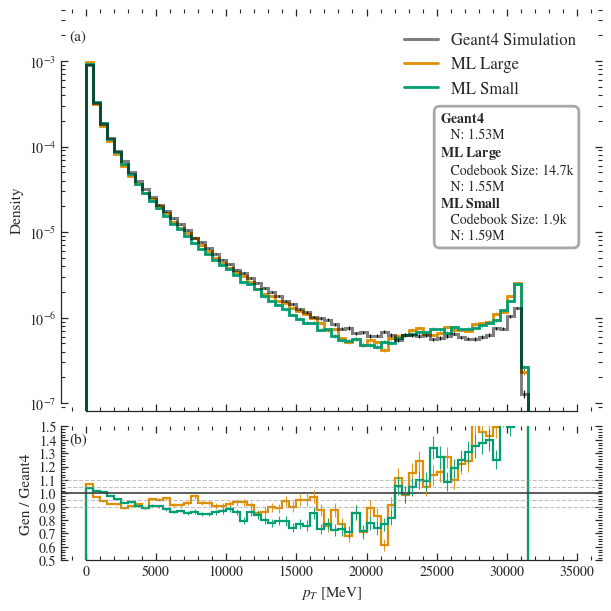

eta


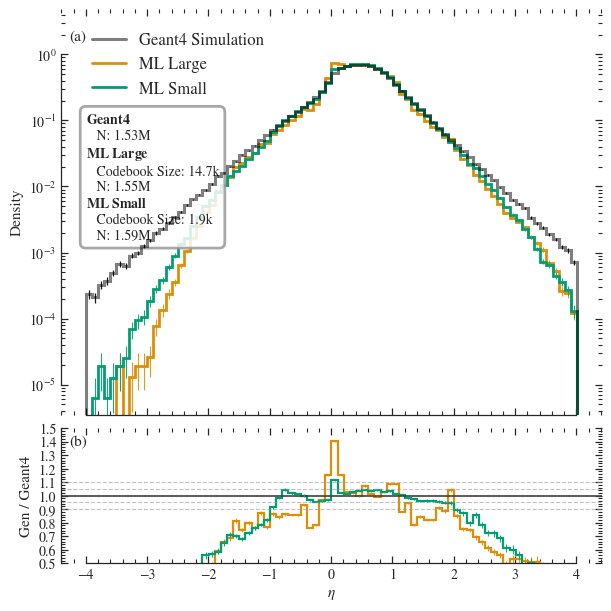

phi


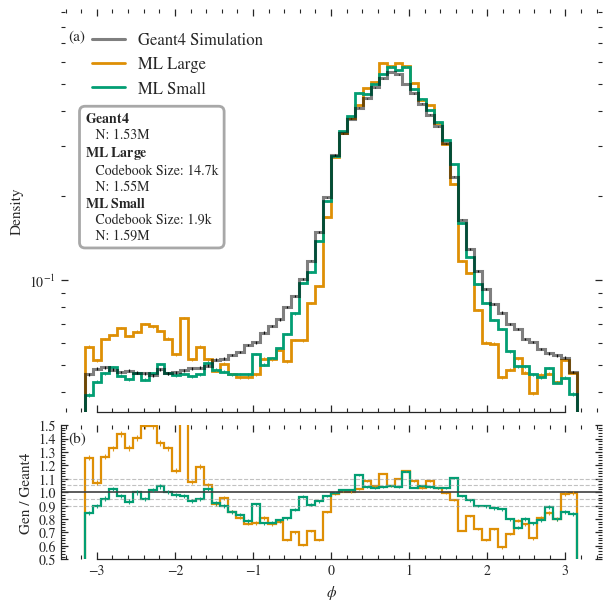

leading particles
pt


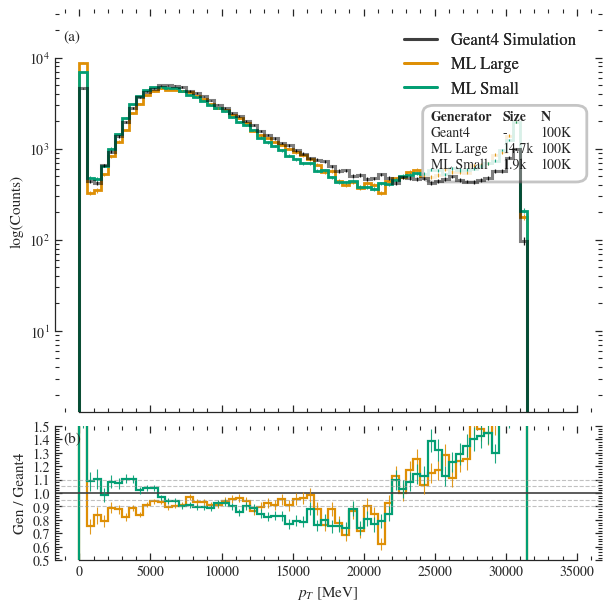

eta


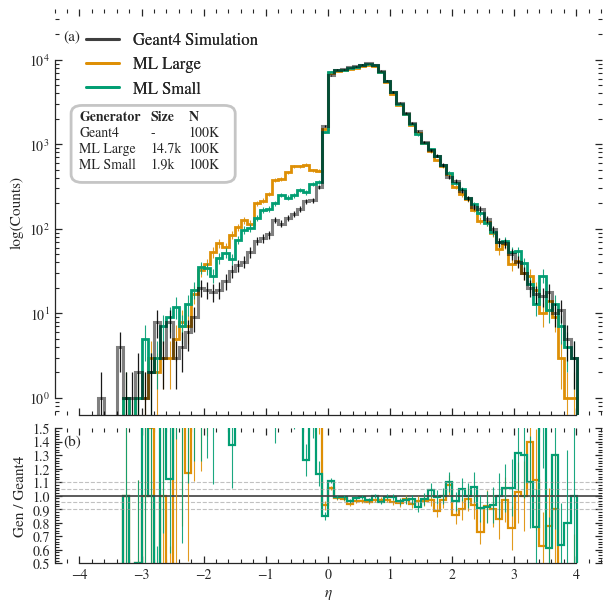

phi


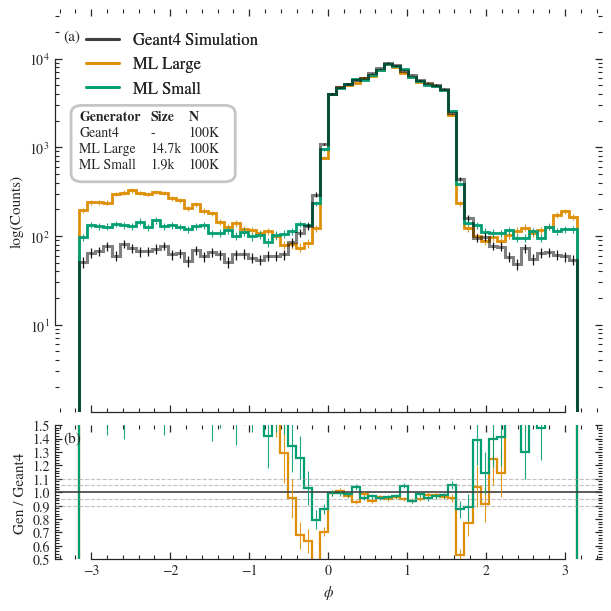

In [ ]:
all_columns = ["pt", "eta", "phi"]
# models_legend_titles = ['Geant4 Simulation', 'Codebook Size: 14.7k', 'Codebook Size: 1.9k tokens']
models_legend_titles = ['Geant4 Simulation', 'ML Large', 'ML Small']

print(f"all outgoing particles")
for column_name in all_columns:
    print(f"{column_name}")
    relevant_column_pos = analv2.plotting_v2.verbose_columns.index(column_name)
    
    relevant_real_data = next(iter(real_secondaries.values()))[:, :, relevant_column_pos].ravel()
    relevant_real_data = relevant_real_data[~np.isnan(relevant_real_data)]
    relevant_gen_data = {mn: gen_secondaries[mn][:, :, relevant_column_pos].ravel() for mn in models_to_compare}
    relevant_gen_data = {mn: v[~np.isnan(v)] for mn, v in relevant_gen_data.items()}
    
    spec_text = (
        r"$ \bf{Geant4} $" "\n"
        f"   N: {numerize.numerize(len(relevant_real_data))}\n"
        r"$ \bf{ML \ Large} $" "\n"
         "   Codebook Size: 14.7k\n"
        f"   N: {numerize.numerize(len(relevant_gen_data['model_10M_9_exp9_vdimlr_1']))}\n"
        r"$ \bf{ML \ Small} $" "\n"
         "   Codebook Size: 1.9k\n"
        f"   N: {numerize.numerize(len(relevant_gen_data['model_10M_12_inclrrestarts_3']))}"
    )
    
    spec_table_rows = [
        ("Geant4", "-", numerize.numerize(len(relevant_real_data))),
        ("ML Large", "14.7k", numerize.numerize(len(relevant_gen_data['model_10M_9_exp9_vdimlr_1']))),
        ("ML Small", "1.9k", numerize.numerize(len(relevant_gen_data['model_10M_12_inclrrestarts_3']))),
    ]
    
    analv2.plotting_v2.plot_dist_and_ratio_cont(
        column_name=column_name,
        edges=None,
        ref_vals=relevant_real_data,
        comp_vals_dict=relevant_gen_data,
        model_legend_titles=models_legend_titles,
        model_names=models_to_compare,
        density=True,
        use_log=True,
        out_file=None,
        title=None,
        spec_text=spec_text,
        # spec_table_rows=spec_table_rows
    )
    
print(f"leading particles")
for column_name in all_columns:
    print(f"{column_name}")
    relevant_column_pos = analv2.plotting_v2.verbose_columns.index(column_name)
    
    relevant_real_data = next(iter(real_leadings.values()))[:, relevant_column_pos].ravel()
    relevant_real_data = relevant_real_data[~np.isnan(relevant_real_data)]
    relevant_gen_data = {mn: gen_leadings[mn][:, relevant_column_pos].ravel() for mn in models_to_compare}
    relevant_gen_data = {mn: v[~np.isnan(v)] for mn, v in relevant_gen_data.items()}
    
    spec_text = (
        r"$ \bf{Geant4} $" "\n"
        f"   N: {numerize.numerize(len(relevant_real_data))}\n"
        r"$ \bf{ML \ Large} $" "\n"
         "   Codebook Size: 14.7k\n"
        f"   N: {numerize.numerize(len(relevant_gen_data['model_10M_9_exp9_vdimlr_1']))}\n"
        r"$ \bf{ML \ Small} $" "\n"
         "   Codebook Size: 1.9k\n"
        f"   N: {numerize.numerize(len(relevant_gen_data['model_10M_12_inclrrestarts_3']))}"
    )
    
    spec_table_rows = [
        ("Geant4", "-", numerize.numerize(len(relevant_real_data))),
        ("ML Large", "14.7k", numerize.numerize(len(relevant_gen_data['model_10M_9_exp9_vdimlr_1']))),
        ("ML Small", "1.9k", numerize.numerize(len(relevant_gen_data['model_10M_12_inclrrestarts_3']))),
    ]
    
    analv2.plotting_v2.plot_dist_and_ratio_cont(
        column_name=column_name,
        edges=None,
        ref_vals=relevant_real_data,
        comp_vals_dict=relevant_gen_data,
        model_legend_titles=models_legend_titles,
        model_names=models_to_compare,
        density=False,
        use_log=True,
        out_file=None,
        title=None,
        spec_table_rows=spec_table_rows
    )